In [8]:
import os

print(os.listdir("/kaggle/input"))

['datasets', 'notebooks']


In [9]:
import os

print(os.listdir("/kaggle/input/datasets"))

['drgfreeman']


In [10]:
import os

print(os.listdir("/kaggle/input/datasets/drgfreeman"))

['rockpaperscissors']


In [11]:
import os

path = "/kaggle/input/datasets/drgfreeman/rockpaperscissors"

print(os.listdir(path))

['paper', 'rock', 'rps-cv-images', 'README_rpc-cv-images.txt', 'scissors']


In [12]:
import os

base_path = "/kaggle/input/datasets/drgfreeman/rockpaperscissors"

for category in ["rock", "paper", "scissors"]:
    folder = os.path.join(base_path, category)
    images = os.listdir(folder)
    print(category, ":", len(images), "images")

rock : 726 images
paper : 712 images
scissors : 750 images


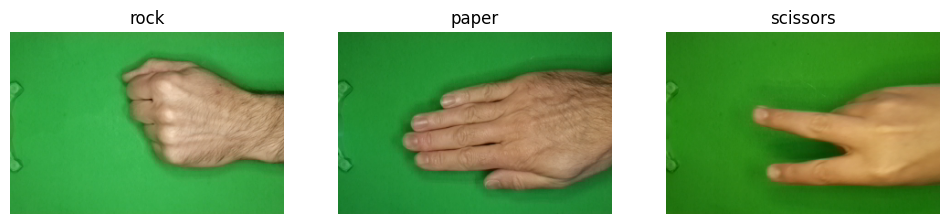

In [13]:
import matplotlib.pyplot as plt
import os
from PIL import Image

base_path = "/kaggle/input/datasets/drgfreeman/rockpaperscissors"

classes = ["rock", "paper", "scissors"]

plt.figure(figsize=(12, 4))

for i, category in enumerate(classes):
    folder = os.path.join(base_path, category)
    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)

    image = Image.open(image_path)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis("off")

plt.show()

In [14]:
from PIL import Image
import os

base_path = "/kaggle/input/datasets/drgfreeman/rockpaperscissors"

image_path = os.path.join(base_path, "rock", os.listdir(os.path.join(base_path, "rock"))[0])

image = Image.open(image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (300, 200)
Image mode: RGB


In [15]:
import tensorflow as tf

base_path = "/kaggle/input/datasets/drgfreeman/rockpaperscissors"

img_size = (224, 224)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=123
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    base_path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=123
)

print("Classes:", train_dataset.class_names)

Found 4376 files belonging to 4 classes.
Using 3501 files for training.


2026-10-02 17:38:03.867786: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 4376 files belonging to 4 classes.
Using 875 files for validation.
Classes: ['paper', 'rock', 'rps-cv-images', 'scissors']


In [16]:
import os

path = "/kaggle/input/datasets/drgfreeman/rockpaperscissors/rps-cv-images"

print(os.listdir(path))

['paper', 'rock', 'README_rpc-cv-images.txt', 'scissors']


In [17]:
import tensorflow as tf

base_path = "/kaggle/input/datasets/drgfreeman/rockpaperscissors/rps-cv-images"

img_size = (224, 224)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=123
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    base_path,
    image_size=img_size,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=123
)

print("Classes:", train_dataset.class_names)

Found 2188 files belonging to 3 classes.
Using 1751 files for training.
Found 2188 files belonging to 3 classes.
Using 437 files for validation.
Classes: ['paper', 'rock', 'scissors']


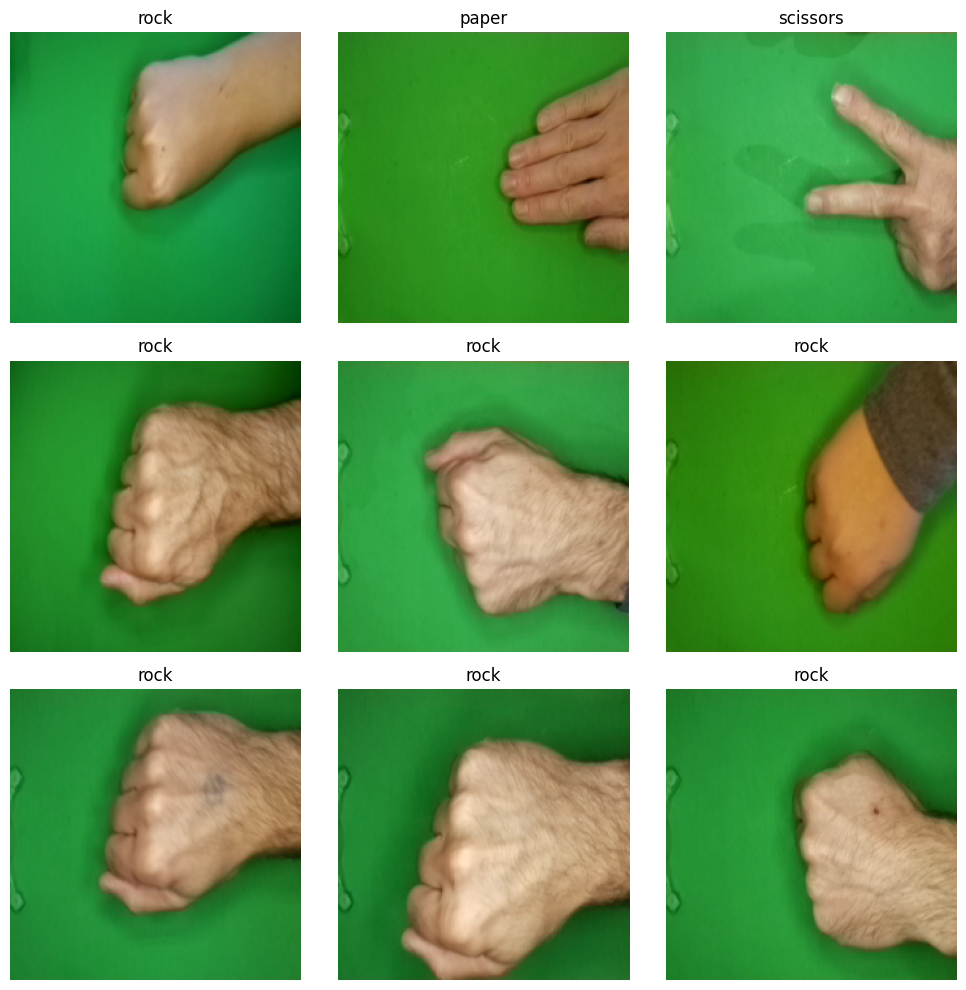

In [18]:
import matplotlib.pyplot as plt

class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

validation_dataset = validation_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

print("Normalization completed.")

Normalization completed.


In [20]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation created.")

Data augmentation created.


In [21]:
import tensorflow as tf

model = tf.keras.Sequential([
    
    # Data augmentation
    data_augmentation,

    # First CNN layer
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Second CNN layer
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Third CNN layer
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Convert feature maps into one vector
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(128, activation="relu"),

    # Prevent overfitting
    tf.keras.layers.Dropout(0.5),

    # 3 classes: paper, rock, scissors
    tf.keras.layers.Dense(3, activation="softmax")
])

model.build(input_shape=(None, 224, 224, 3))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [23]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.4186 - loss: 1.1406 - val_accuracy: 0.6476 - val_loss: 0.8313
Epoch 2/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.6374 - loss: 0.8458 - val_accuracy: 0.6476 - val_loss: 0.8122
Epoch 3/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7887 - loss: 0.5543 - val_accuracy: 0.8947 - val_loss: 0.3076
Epoch 4/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8544 - loss: 0.4126 - val_accuracy: 0.9519 - val_loss: 0.1728
Epoch 5/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8961 - loss: 0.3048 - val_accuracy: 0.9542 - val_loss: 0.1515


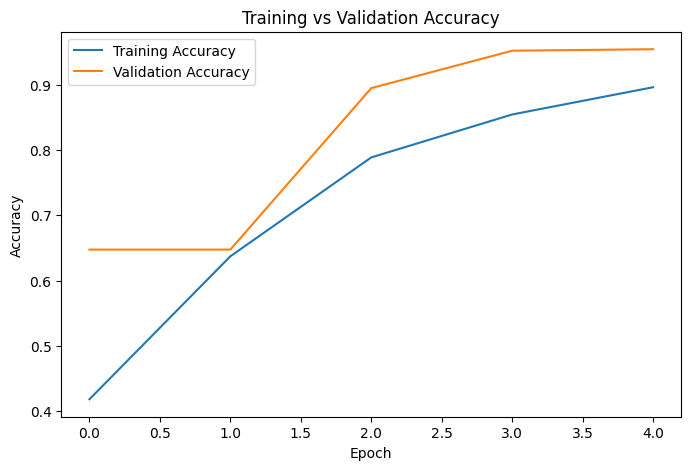

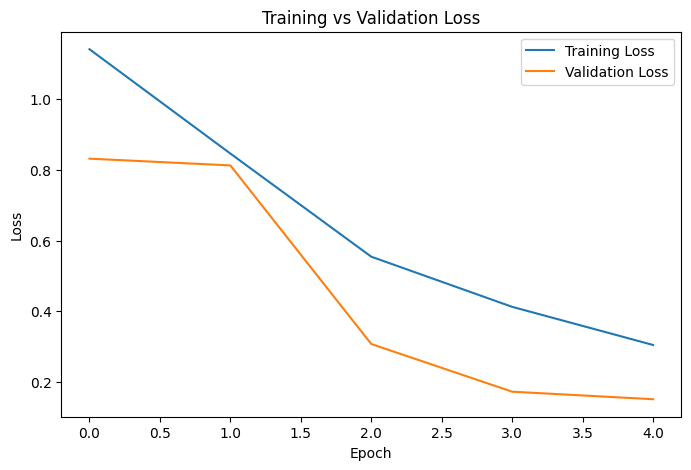

In [24]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicted class: rock
Prediction probabilities: [0.03216729 0.96174407 0.00608863]


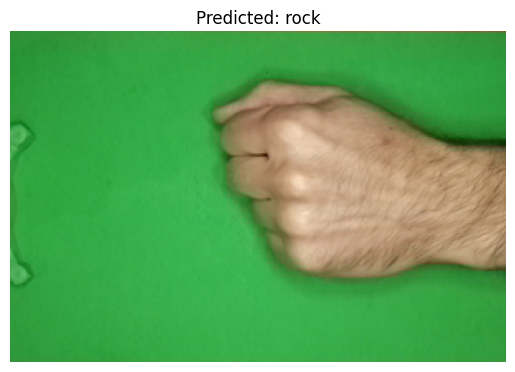

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# Choose one image
image_path = os.path.join(
    base_path,
    "rock",
    os.listdir(os.path.join(base_path, "rock"))[0]
)

# Load and resize image
image = load_img(image_path, target_size=(224, 224))

# Convert image to array
image_array = img_to_array(image)

# Normalize pixel values
image_array = image_array / 255.0

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# Make prediction
prediction = model.predict(image_array)

# Get predicted class
predicted_class = class_names[np.argmax(prediction)]

print("Predicted class:", predicted_class)
print("Prediction probabilities:", prediction[0])

# Display image
plt.imshow(load_img(image_path))
plt.title("Predicted: " + predicted_class)
plt.axis("off")
plt.show()

In [26]:
# Evaluate the model on the complete validation dataset

validation_loss, validation_accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.9542 - loss: 0.1515
Validation Loss: 0.15151993930339813
Validation Accuracy: 0.9542334079742432


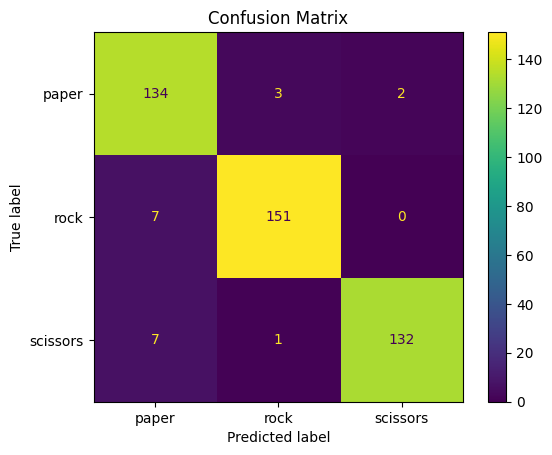

In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the true labels and predictions
y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

       paper       0.91      0.96      0.93       139
        rock       0.97      0.96      0.96       158
    scissors       0.99      0.94      0.96       140

    accuracy                           0.95       437
   macro avg       0.95      0.95      0.95       437
weighted avg       0.96      0.95      0.95       437

